# GISC 4381/6321 — Lab 5: Choropleth Mapping & ESDA

This week's notebook covers choropleth classification schemes and exploratory spatial data
analysis (ESDA): global Moran's I, join counts, and local indicators of spatial association
(LISA). We'll use Guerry's 1830s "moral statistics of France" dataset — a real, classic dataset
bundled as an example with PySAL — throughout.

### Setup

If these aren't already installed in your environment:


In [1]:
# !pip install geopandas libpysal esda mapclassify matplotlib numpy


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
import libpysal
from libpysal.weights import Queen, KNN

import esda
from esda.moran import Moran, Moran_Local
from esda.join_counts import Join_Counts
from esda.getisord import G_Local

import mapclassify

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 6)


/tmp/ipykernel_804/1553464792.py:4: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


## 1. Loading the Guerry dataset

`libpysal.examples` ships a small library of classic spatial-analysis datasets. The first time
you load one, PySAL downloads it (so you'll need internet access); after that it's cached
locally. We'll use **Guerry** — crime, literacy, suicide, and other "moral statistics" for the 86
departments of France, collected by André-Michel Guerry around 1830.


In [3]:
guerry_data = libpysal.examples.load_example("Guerry")
guerry = gpd.read_file(guerry_data.get_path("guerry.shp"))
guerry.head()

,dept,Region,Dprtmnt,Crm_prs,Crm_prp,Litercy,Donatns,Infants,Suicids,MainCty,...,Infntcd,Dntn_cl,Lottery,Desertn,Instrct,Prsttts,Distanc,Area,Pop1831,geometry
0,1.0,E,Ain,28870.0,15890.0,37.0,5098.0,33120.0,35039.0,2.0,...,60.0,69.0,41.0,55.0,46.0,13.0,218.372,5762.0,346.03,"POLYGON ((801150.000 2092615.000, 800669.000 2..."
1,2.0,N,Aisne,26226.0,5521.0,51.0,8901.0,14572.0,12831.0,2.0,...,82.0,36.0,38.0,82.0,24.0,327.0,65.945,7369.0,513.00,"POLYGON ((729326.000 2521619.000, 729320.000 2..."
2,3.0,C,Allier,26747.0,7925.0,13.0,10973.0,17044.0,114121.0,2.0,...,42.0,76.0,66.0,16.0,85.0,34.0,161.927,7340.0,298.26,"POLYGON ((710830.000 2137350.000, 711746.000 2..."
3,4.0,E,Basses-Alpes,12935.0,7289.0,46.0,2733.0,23018.0,14238.0,1.0,...,12.0,37.0,80.0,32.0,29.0,2.0,351.399,6925.0,155.90,"POLYGON ((882701.000 1920024.000, 882408.000 1..."
4,5.0,E,Hautes-Alpes,17488.0,8174.0,69.0,6962.0,23076.0,16171.0,1.0,...,23.0,64.0,79.0,35.0,7.0,1.0,320.280,5549.0,129.10,"POLYGON ((886504.000 1922890.000, 885733.000 1..."


Shapefiles truncate column names to 10 characters, so the exact spelling in your copy might not
match what you'd expect. Run `guerry.columns.tolist()` and look for the variable you want.


In [4]:
print(guerry.columns.tolist())

['dept', 'Region', 'Dprtmnt', 'Crm_prs', 'Crm_prp', 'Litercy', 'Donatns', 'Infants', 'Suicids', 'MainCty', 'Wealth', 'Commerc', 'Clergy', 'Crm_prn', 'Infntcd', 'Dntn_cl', 'Lottery', 'Desertn', 'Instrct', 'Prsttts', 'Distanc', 'Area', 'Pop1831', 'geometry']


For the rest of this notebook we'll work with **literacy** (percent of military conscripts who
could read and write). Find its exact column name and pull it out — the small helper below
searches for it case-insensitively so this cell keeps working even if your copy of the shapefile
spells it slightly differently.


In [5]:
literacy_col = [c for c in guerry.columns if "LIT" in c.upper()][0]
print("Using column:", literacy_col)

guerry = guerry.rename(columns={literacy_col: "literacy"})
guerry["literacy"] = guerry["literacy"].astype(float)
guerry[["literacy"]].describe()

Using column: Litercy


,literacy
count,85.000000
mean,39.141176
std,17.434335
min,12.000000
25%,25.000000
50%,38.000000
75%,52.000000
max,74.000000


## 2. Choropleth Mapping

### 2.1 A first look


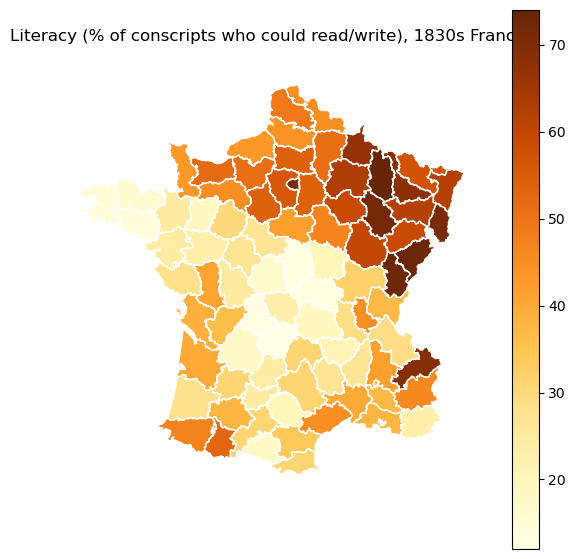

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
guerry.plot(column="literacy", cmap="YlOrBr", edgecolor="white", legend=True, ax=ax)
ax.set_title("Literacy (% of conscripts who could read/write), 1830s France")
ax.set_axis_off()
plt.show()

### 2.2 Classification schemes

`geopandas`'s `.plot()` hands classification off to `mapclassify` via the `scheme` argument.


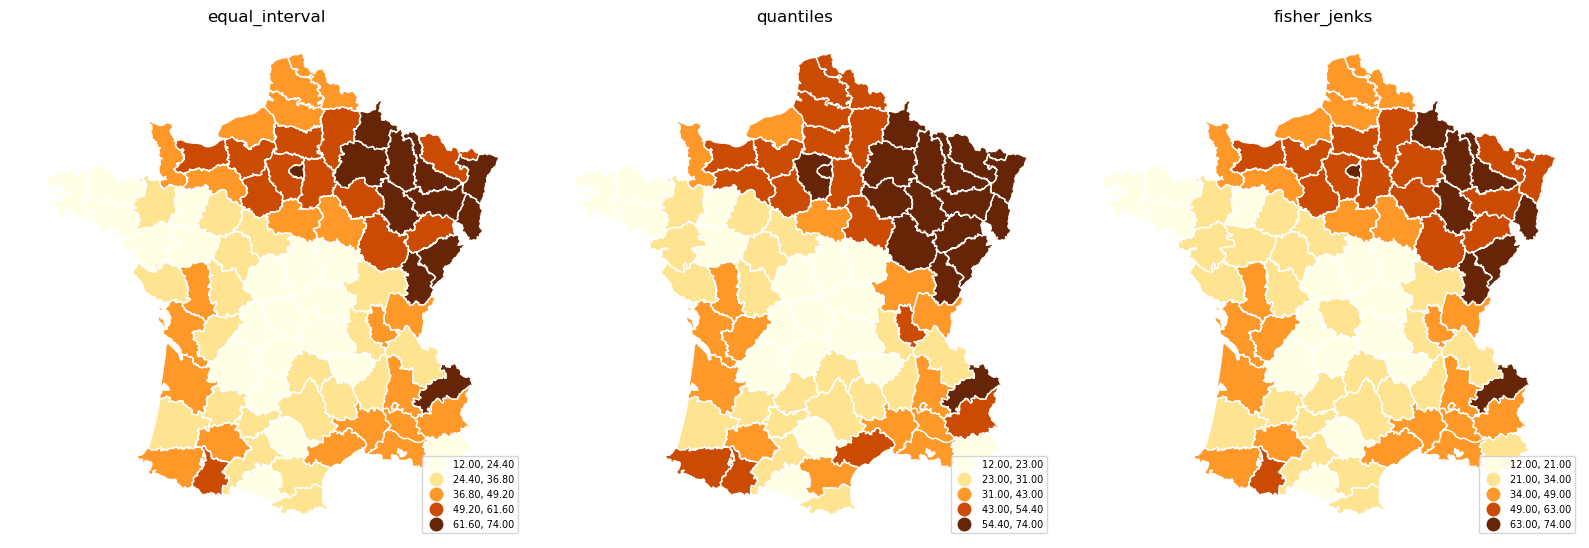

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, scheme in zip(axes, ["equal_interval", "quantiles", "fisher_jenks"]):
    guerry.plot(column="literacy", scheme=scheme, k=5, cmap="YlOrBr",
                 edgecolor="white", legend=True, ax=ax,
                 legend_kwds={"fontsize": 7, "loc": "lower right"})
    ax.set_title(scheme)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

You can also run a classifier on its own, without plotting, to inspect the bin edges directly:


In [8]:
classifier = mapclassify.Quantiles(guerry["literacy"], k=5)
print(classifier)


Quantiles

   Interval      Count
----------------------
[12.00, 23.00] |    18
(23.00, 31.00] |    19
(31.00, 43.00] |    15
(43.00, 54.40] |    16
(54.40, 74.00] |    17


## 3. Building a Spatial Weights Matrix

Every statistic below needs a definition of "neighbor." We'll use Queen contiguity, as in the
spatial weights lab.


In [9]:
w = Queen.from_dataframe(guerry, use_index=False)
w.transform = "r"
print("Average number of neighbors:", w.mean_neighbors)
print("Islands (zero neighbors):", w.islands)


Average number of neighbors: 4.9411764705882355
Islands (zero neighbors): []


## 4. Global Spatial Autocorrelation

### 4.1 Moran's I


In [10]:
mi = Moran(guerry["literacy"], w)
print(f"Moran's I: {mi.I:.3f}")
print(f"p_sim:     {mi.p_sim:.3f}")


Moran's I: 0.718
p_sim:     0.001


The Moran scatterplot (value vs. its spatial lag) is the picture behind that number:


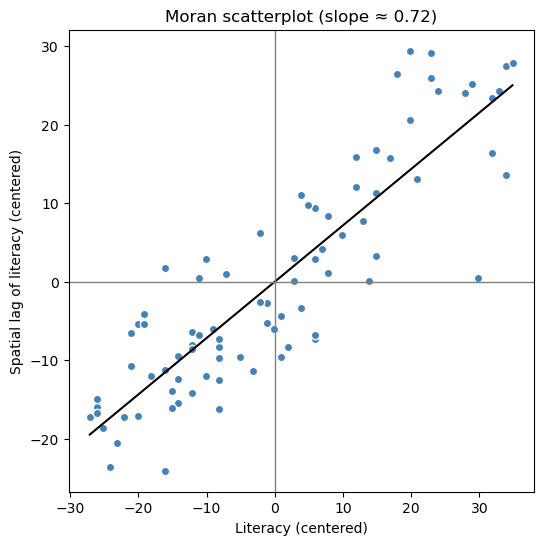

In [11]:
lag = libpysal.weights.lag_spatial(w, guerry["literacy"])
z = guerry["literacy"] - guerry["literacy"].mean()
z_lag = lag - lag.mean()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(z, z_lag, color="steelblue", edgecolor="white")
m, b = np.polyfit(z, z_lag, 1)
xs = np.linspace(z.min(), z.max(), 10)
ax.plot(xs, m * xs + b, color="black")
ax.axhline(0, color="grey", linewidth=1)
ax.axvline(0, color="grey", linewidth=1)
ax.set_xlabel("Literacy (centered)")
ax.set_ylabel("Spatial lag of literacy (centered)")
ax.set_title(f"Moran scatterplot (slope ≈ {m:.2f})")
plt.show()


### 4.2 Join Counts

Join counts need a binary variable, so we'll split literacy at its median.

> **Note on package versions:** the exact attribute name `Join_Counts` uses for its p-value has
> shifted across `esda` releases. If `jc.p_sim_bb` below raises an `AttributeError`, run
> `dir(jc)` to find the equivalent attribute in your installed version.


In [12]:
guerry["high_literacy"] = (guerry["literacy"] > guerry["literacy"].median()).astype(int)

jc = Join_Counts(guerry["high_literacy"], w)
print("BB (both high-literacy):", jc.bb)
print("WW (both low-literacy): ", jc.ww)
print("BW (different):         ", jc.bw)
print("p-value (BB):", getattr(jc, "p_sim_bb", "check dir(jc) for the exact attribute name"))


BB (both high-literacy): 70.0
WW (both low-literacy):  94.0
BW (different):          46.0
p-value (BB): 0.001


## 5. Local Spatial Autocorrelation

### 5.1 Local Moran's I (LISA)


In [13]:
lisa = Moran_Local(guerry["literacy"], w)

quadrant_labels = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
guerry["lisa_quadrant"] = [quadrant_labels[q] for q in lisa.q]
guerry["lisa_significant"] = lisa.p_sim < 0.05

guerry[["literacy", "lisa_quadrant", "lisa_significant"]].head(10)


,literacy,lisa_quadrant,lisa_significant
0,37.0,LH,False
1,51.0,HH,True
2,13.0,LL,True
3,46.0,HH,False
4,69.0,HL,False
5,27.0,LL,False
6,67.0,HH,True
7,18.0,LL,False
8,59.0,HH,True
9,34.0,LL,False


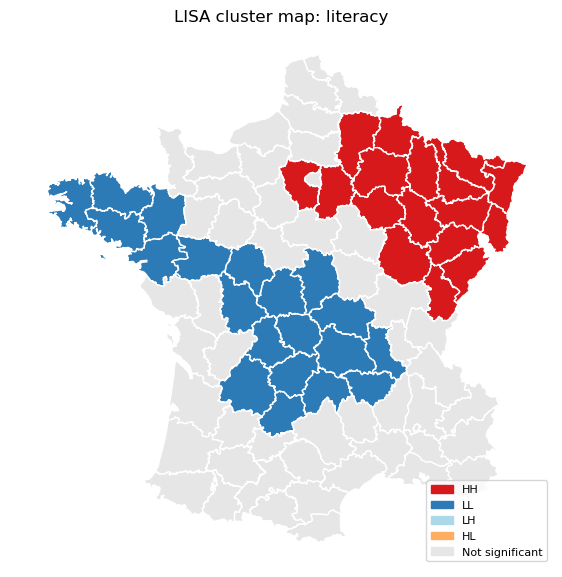

In [14]:
cluster_colors = {"HH": "#d7191c", "LL": "#2c7bb6", "LH": "#abd9e9", "HL": "#fdae61"}
guerry["cluster_color"] = "#e7e6e6"  # not significant
sig = guerry["lisa_significant"]
guerry.loc[sig, "cluster_color"] = guerry.loc[sig, "lisa_quadrant"].map(cluster_colors)

fig, ax = plt.subplots(figsize=(7, 7))
guerry.plot(color=guerry["cluster_color"], edgecolor="white", ax=ax)
ax.set_title("LISA cluster map: literacy")
ax.set_axis_off()

from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in {**cluster_colors, "Not significant": "#e7e6e6"}.items()]
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.show()


### 5.2 Local Getis-Ord G*


/home/jovyan/.local/iguide/lib/python3.8/site-packages/esda/getisord.py:615: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  warnings.warn(


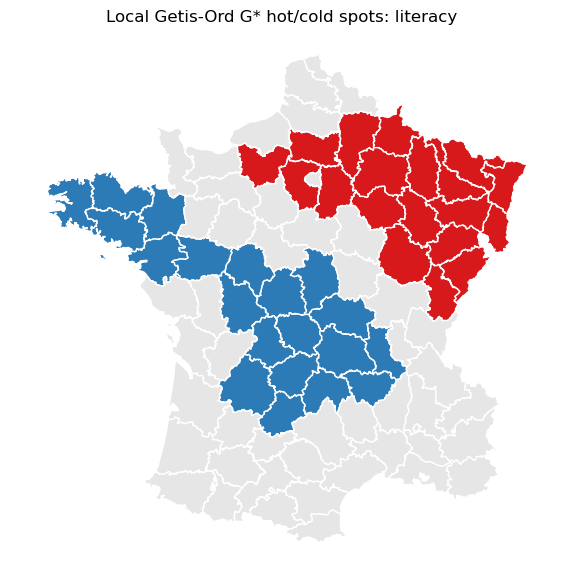

In [15]:
g_local = G_Local(guerry["literacy"], w, transform="R", star=True)

guerry["g_zscore"] = g_local.Zs
guerry["g_significant"] = g_local.p_sim < 0.05
guerry["hot_cold"] = np.where(guerry["g_zscore"] > 0, "Hot", "Cold")

fig, ax = plt.subplots(figsize=(7, 7))
colors = np.where(~guerry["g_significant"], "#e7e6e6",
          np.where(guerry["hot_cold"] == "Hot", "#d7191c", "#2c7bb6"))
guerry.plot(color=colors, edgecolor="white", ax=ax)
ax.set_title("Local Getis-Ord G* hot/cold spots: literacy")
ax.set_axis_off()
plt.show()


## 6. Next steps

- Try all of the above on a different variable in `guerry` (crime, donations, suicides).
- Try `KNN.from_dataframe(guerry, k=4)` instead of Queen contiguity, and see how much your
  results change.
- The `splot` package (`splot.esda.moran_scatterplot`) will draw the quadrant-colored Moran
  scatterplot in one line, if you'd rather not build it by hand.
